In [1]:
import requests
import os
import pandas as pd
import numpy as np


from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Data download

url = "https://esploradati.istat.it/SDMXWS/rest/data/41_983"
header = {"Accept": "application/vnd.sdmx.data+csv;version=1.0.0"}

if not os.path.exists("../data/raw/raw_data.csv"):
    raw_data = requests.get(url, headers=header)
    # Creating the local file
    with open("../data/raw/raw_data.csv", "w", encoding="utf-8") as f:
        f.write(raw_data.text)   

In [3]:
# Taking a look at the raw data

raw_df = pd.read_csv("../data/raw/raw_data.csv")
raw_df.head()

,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,OBS_STATUS,NOTE_DS,NOTE_REF_AREA,NOTE_DATA_TYPE,NOTE_RESULT,NOTE_TIME_PERIOD,BASE_PER,UNIT_MEAS,UNIT_MULT
0,IT1:41_983(1.0),A,1001,KILLINJ,F,2001,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IT1:41_983(1.0),A,1001,KILLINJ,F,2002,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IT1:41_983(1.0),A,1001,KILLINJ,F,2003,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IT1:41_983(1.0),A,1001,KILLINJ,F,2004,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IT1:41_983(1.0),A,1001,KILLINJ,F,2005,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
kept_columns = ["REF_AREA","DATA_TYPE","RESULT","TIME_PERIOD","OBS_VALUE"]
df = raw_df[kept_columns]
df.head()

# Removed empty "NaN" columns and kept only the information relevant to the analysis

,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE
0,1001,KILLINJ,F,2001,10
1,1001,KILLINJ,F,2002,10
2,1001,KILLINJ,F,2003,7
3,1001,KILLINJ,F,2004,13
4,1001,KILLINJ,F,2005,2


I'll now check the datatypes to avoid wrong datatypes and null values

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 573552 entries, 0 to 573551
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   REF_AREA     573552 non-null  int64
 1   DATA_TYPE    573552 non-null  str  
 2   RESULT       573552 non-null  str  
 3   TIME_PERIOD  573552 non-null  int64
 4   OBS_VALUE    573552 non-null  int64
dtypes: int64(3), str(2)
memory usage: 21.9 MB


In [6]:
# Optional
# the dataset already shows no missing values, but twe can double check by running these individually

df[df["REF_AREA"].isnull()]
df[df["DATA_TYPE"].isnull()]
df[df["RESULT"].isnull()]
df[df["TIME_PERIOD"].isnull()]
df[df["OBS_VALUE"].isnull()]


,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE


In [7]:
#I want to see what kinds of accident there are

df["DATA_TYPE"].value_counts()

# The number of injuries and deaths is higher than the number of accidents because multiple people can be involved in the same accident, so it makes sense
# What's strange is that KILLINJ is exactly double the ROADACC

DATA_TYPE
KILLINJ    382368
ROADACC    191184
Name: count, dtype: int64

In [8]:
df["RESULT"].value_counts()

# The count for each RESULT category is identical, which seems unusual
# This makes me suspect that the dataset creates one row for every RESULT type for each municipality and year and
# when no event occurs for a specific RESULT category, OBS_VALUE is set to 0
# Since I am counting rows rather than summing OBS_VALUE, records with a value of 0 are included in the count
# I verified this by importing the CSV into Excel and filtering a single municipality and year, and I confirm this is the structure

RESULT
F    191184
M    191184
9    191184
Name: count, dtype: int64

After checking on the internet, I found out that "F" stands for "Feriti" (Injuries) and "M" stands for "Morti" (Deaths)
Although the dataset uses English column names, these category codes are in Italian

In [9]:
print(df.groupby("RESULT")["OBS_VALUE"].sum())

# Grouping  the data by RESULT and sum OBS_VALUE
# As expected, the total number of injuries is much higher than the total number of deaths, which is realistic

# By making another research, I found out that the value "9" represents "Not applicable" in ISTAT terminology
# Since it's not relevant, it will be excluded

RESULT
9    4779141
F    6709026
M     101944
Name: OBS_VALUE, dtype: int64


Now I will proceed with the merge using the SITUAS dataset
Before doing so, I'll check the data type of the columns to make sure the primary keys they are compatible

In [10]:
situas_local_file = "../data/raw/SITUAS_2024.csv"

situas_df = pd.read_csv(situas_local_file, sep=';', encoding='latin1') # UTF-8 encoding caused issues with Italian accented characters
situas_df.head()

,ï»¿Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),Codice Provincia/Uts,Codice Comune (alfanumerico),Codice Comune (numerico),Comune,Comune (dizione straniera),Sigla automobilistica,Capoluogo di Provincia/Uts,Capoluogo di Regione,Popolazione legale,Anno Censimento,Superficie (Kmq),Anno (Superficie),Popolazione residente,Anno (Popolazione residente)
0,1,1,1,201,1001,1001,AgliÃ¨,NaN,TO,0,0,2562,2021,"13,1463",2024,2585,2024
1,1,1,1,201,1002,1002,Airasca,NaN,TO,0,0,3660,2021,"15,7393",2024,3695,2024
2,1,1,1,201,1003,1003,Ala di Stura,NaN,TO,0,0,467,2021,"46,3316",2024,463,2024
3,1,1,1,201,1004,1004,Albiano d'Ivrea,NaN,TO,0,0,1637,2021,"11,7397",2024,1624,2024
4,1,1,1,201,1006,1006,Almese,NaN,TO,0,0,6331,2021,"17,8741",2024,6297,2024


In [11]:
situas_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7896 entries, 0 to 7895
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   ï»¿Codice Ripartizione geografica  7896 non-null   int64
 1   Codice Regione                     7896 non-null   int64
 2   Codice Provincia (Storico)         7896 non-null   int64
 3   Codice Provincia/Uts               7896 non-null   int64
 4   Codice Comune (alfanumerico)       7896 non-null   int64
 5   Codice Comune (numerico)           7896 non-null   int64
 6   Comune                             7895 non-null   str  
 7   Comune (dizione straniera)         124 non-null    str  
 8   Sigla automobilistica              7804 non-null   str  
 9   Capoluogo di Provincia/Uts         7896 non-null   int64
 10  Capoluogo di Regione               7896 non-null   int64
 11  Popolazione legale                 7896 non-null   int64
 12  Anno Censimento                

I noticed that the Superficie (Kmq) column has string as type, which makes it useless for analysis
After investigating, I found that the dataset uses commas as decimal separators, while Python expects dots when converting values to numeric types
To fix it, I will replace commas with dots before converting the column to a numeric data type.

In [12]:
situas_clean = situas_df[["Codice Comune (numerico)", "Comune", "Superficie (Kmq)", "Popolazione residente"]].copy()

situas_clean["Superficie (Kmq)"] = (
        situas_clean["Superficie (Kmq)"].astype(str).str.replace(".","", regex =False)
        .str.replace(",",".", regex =False).astype(float))

situas_clean.info()

# I removerd the dots and then replaced the commas with dots
#regex false is used to avoid that dots get considered as wildcards

<class 'pandas.DataFrame'>
RangeIndex: 7896 entries, 0 to 7895
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Codice Comune (numerico)  7896 non-null   int64  
 1   Comune                    7895 non-null   str    
 2   Superficie (Kmq)          7896 non-null   float64
 3   Popolazione residente     7896 non-null   int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 246.9 KB


For the merge, I will use REF_AREA from the ISTAT dataset and Municipality Code from SITUAS, as both columns use the are type int64 and match in content

In [13]:
situas_df["Codice Comune (numerico)"].dtype

dtype('int64')

In [14]:
merge_dfs = df.merge(
    situas_clean,
    left_on="REF_AREA",
    right_on="Codice Comune (numerico)",
    how="inner"
)

merge_dfs.head()

,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,Codice Comune (numerico),Comune,Superficie (Kmq),Popolazione residente
0,1001,KILLINJ,F,2001,10,1001,AgliÃ¨,13.1463,2585
1,1001,KILLINJ,F,2002,10,1001,AgliÃ¨,13.1463,2585
2,1001,KILLINJ,F,2003,7,1001,AgliÃ¨,13.1463,2585
3,1001,KILLINJ,F,2004,13,1001,AgliÃ¨,13.1463,2585
4,1001,KILLINJ,F,2005,2,1001,AgliÃ¨,13.1463,2585


In [15]:
# I successfully merged the datasets. Removing the duplicated column now (REF_AREA)

merge_dfs.drop(columns=["Codice Comune (numerico)"], inplace=True)
merge_dfs.head()

,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,Comune,Superficie (Kmq),Popolazione residente
0,1001,KILLINJ,F,2001,10,AgliÃ¨,13.1463,2585
1,1001,KILLINJ,F,2002,10,AgliÃ¨,13.1463,2585
2,1001,KILLINJ,F,2003,7,AgliÃ¨,13.1463,2585
3,1001,KILLINJ,F,2004,13,AgliÃ¨,13.1463,2585
4,1001,KILLINJ,F,2005,2,AgliÃ¨,13.1463,2585


In [16]:
# Renaming columns

rename_columns = {
    "REF_AREA": "Codice_comune",
    "DATA_TYPE": "Tipo_dato",
    "RESULT" : "Codice_esito",
    "TIME_PERIOD": "Anno",
    "OBS_VALUE": "Numero_eventi",
    "Superficie (Kmq)": "Superficie_Kmq",
    "Popolazione residente": "Popolazione_residente"


}

merge_dfs.rename(columns=rename_columns, inplace=True)

merge_dfs.head()

,Codice_comune,Tipo_dato,Codice_esito,Anno,Numero_eventi,Comune,Superficie_Kmq,Popolazione_residente
0,1001,KILLINJ,F,2001,10,AgliÃ¨,13.1463,2585
1,1001,KILLINJ,F,2002,10,AgliÃ¨,13.1463,2585
2,1001,KILLINJ,F,2003,7,AgliÃ¨,13.1463,2585
3,1001,KILLINJ,F,2004,13,AgliÃ¨,13.1463,2585
4,1001,KILLINJ,F,2005,2,AgliÃ¨,13.1463,2585


In [17]:
# Pivoting ROADACC and KILLINJ values so they become separate columns instead of rows


merge_dfs_2024 = merge_dfs[merge_dfs["Anno"] == 2024]

pivot = merge_dfs_2024.pivot_table(
    index=["Codice_comune", "Comune", "Anno", "Superficie_Kmq", "Popolazione_residente"],
    columns="Tipo_dato",
    values="Numero_eventi",
    aggfunc="sum"
).reset_index()

pivot.rename(columns={"ROADACC": "Incidenti", "KILLINJ": "Morti_Feriti"}, inplace=True)
#Renaming these columns

pivot.head()


Tipo_dato,Codice_comune,Comune,Anno,Superficie_Kmq,Popolazione_residente,Morti_Feriti,Incidenti
0,1001,AgliÃ¨,2024,13.1463,2585,5,2
1,1002,Airasca,2024,15.7393,3695,9,5
2,1003,Ala di Stura,2024,46.3316,463,2,1
3,1004,Albiano d'Ivrea,2024,11.7397,1624,9,4
4,1006,Almese,2024,17.8741,6297,2,2


In [18]:
# Identifying and fixing municipality names with accent characters that were not properly recognized

comuni_anomali =pivot[pivot["Comune"].str.contains(r"[ÃÂ]", na=False)]["Comune"].unique()
print(comuni_anomali)

<StringArray>
[                'AgliÃ¨',                 'CiriÃ¨',               'CuorgnÃ¨',
              'LusigliÃ¨',              'VestignÃ¨',                   'ViÃ¹',
                'BianzÃ¨',               'SanthiÃ ',        'Bastia MondovÃ¬',
                 'CardÃ¨',
 ...
 'San NicolÃ² d'Arcidano',              'CavagliÃ ',               'BarzanÃ²',
       'Santa Maria HoÃ¨',                  'CirÃ²',           'CirÃ² Marina',
                  'DasÃ ',                'MuggiÃ²',     'San NicolÃ² Gerrei',
               'SenorbÃ¬']
Length: 133, dtype: str


In [19]:
correct_locs = {
    "Ã¨": "è",
    "Ã©": "é",
    "Ã": "à",
    "Ã²": "ò",
    "Ã¹": "ù",
    "Ã¬": "ì"
}

for broken, fixed in correct_locs.items():
    pivot["Comune"] = pivot["Comune"].str.replace(broken, fixed, regex=False)

comuni_anomali = pivot[pivot["Comune"].str.contains("[ÃÂ]", na=False)]["Comune"].unique()
    
print(len(comuni_anomali))

0


Now I'll add the KPIs that I consider useful

In [20]:
# Accidents per 1000 residents
pivot["Accidents_per_1k_residents"] = ((pivot["Incidenti"] / pivot["Popolazione_residente"]) * 1000).round(2)

# Accidents per ksqkm
pivot["Accidents_per_kmsq"] = (pivot["Incidenti"] / pivot["Superficie_Kmq"]).round(2)

# Severity (Deaths and Injuries / Accidents). I'm excluding municipalities with no accidents
pivot["Severity"] = np.where(pivot["Incidenti"] == 0, 0, pivot["Morti_Feriti"] / pivot["Incidenti"])
pivot["Severity"] = pivot["Severity"].round(2)


pivot.head()

Tipo_dato,Codice_comune,Comune,Anno,Superficie_Kmq,Popolazione_residente,Morti_Feriti,Incidenti,Accidents_per_1k_residents,Accidents_per_kmsq,Severity
0,1001,Agliè,2024,13.1463,2585,5,2,0.77,0.15,2.50
1,1002,Airasca,2024,15.7393,3695,9,5,1.35,0.32,1.80
2,1003,Ala di Stura,2024,46.3316,463,2,1,2.16,0.02,2.00
3,1004,Albiano d'Ivrea,2024,11.7397,1624,9,4,2.46,0.34,2.25
4,1006,Almese,2024,17.8741,6297,2,2,0.32,0.11,1.00


In [21]:
# Municipalities with very small populations can distort the KPIs,
# since only a few accidents are enough to push them to the top of the ranking. I'm identifying and excluding them

# I'm also excluding municipalities with fewer than 10,000 residents, as they are unlikely to represent significant investment opportunities

pivot[["Incidenti", "Popolazione_residente", "Superficie_Kmq", "Accidents_per_1k_residents", "Accidents_per_kmsq"]].describe()



Tipo_dato,Incidenti,Popolazione_residente,Superficie_Kmq,Accidents_per_1k_residents,Accidents_per_kmsq
count,6338.000000,6.338000e+03,6338.000000,6338.000000,6338.000000
mean,27.352319,9.094797e+03,41.708021,2.316128,0.807080
std,226.883113,4.622177e+04,54.922311,1.940898,1.858371
min,1.000000,4.700000e+01,0.122200,0.090000,0.000000
25%,2.000000,1.523250e+03,12.374150,1.160000,0.090000
50%,6.000000,3.350500e+03,24.235900,1.890000,0.240000
75%,16.000000,7.771250e+03,48.520075,2.910000,0.730000
max,13924.000000,2.747290e+06,1288.187500,38.960000,42.580000


In [22]:
clean_pivot = pivot[(pivot["Popolazione_residente"] >= 10000) & (pivot["Incidenti"] > 0)].copy()

In [35]:
# Using a linear regression model to evaluate the relationship between population and total accidents

X = clean_pivot[["Popolazione_residente"]].values
y = clean_pivot["Incidenti"].values

model = LinearRegression()
model.fit(X, y)

r_sq = model.score(X, y)
coefficient = model.coef_[0]
intercept = model.intercept_

print(f"R-squared {r_sq:.4f}") # Shows how much of the data variability is explained by the linear regression
print(f"Slope: {coefficient:.4f}")
print(f"Intercept: {intercept:.4f}")

R-squared 0.9615
Slope: 0.0049
Intercept: -49.9544


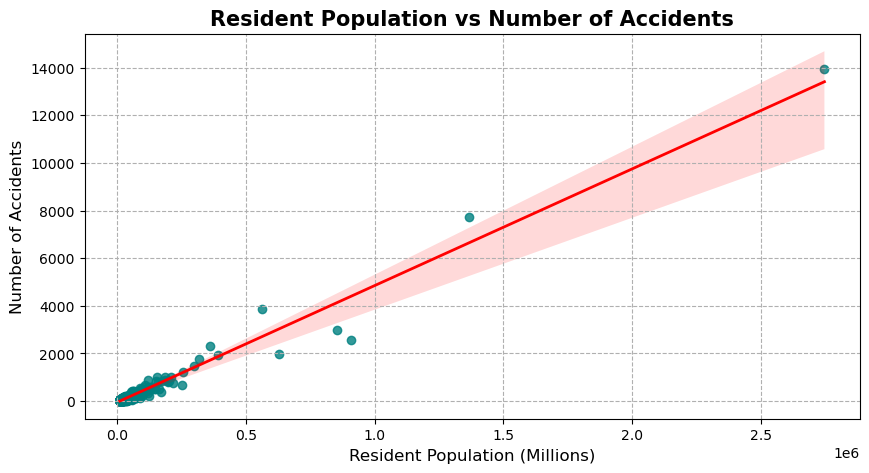

In [24]:
# Linear regression model plot

plt.figure(figsize=(10, 5))
sns.regplot(
    data=clean_pivot, 
    x="Popolazione_residente",
    y="Incidenti",
    scatter_kws={"color":"teal"},
    line_kws={"color":"red", "linewidth": 2}
)

plt.title("Resident Population vs Number of Accidents", fontsize=15, fontweight="bold")
plt.xlabel("Resident Population (Millions)", fontsize=12)
plt.ylabel("Number of Accidents", fontsize=12)
plt.grid(True, linestyle="--")
plt.show()


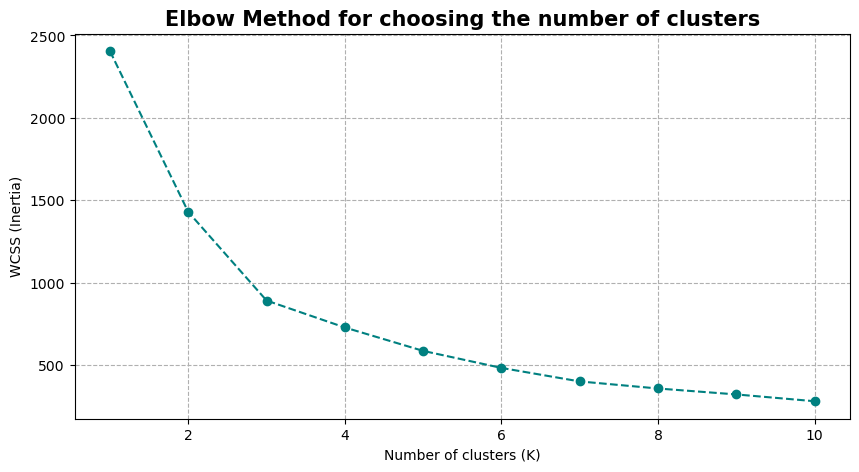

In [25]:
# Using the Elbow Method to find the best amount of clusters 

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Accident rate per 1,000 residents and accidents per km²
X = clean_pivot[["Accidents_per_1k_residents", "Accidents_per_kmsq"]].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Iterations and inertia (Elbow Method)
wcss=[]
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Creating the plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='teal')
plt.title('Elbow Method for choosing the number of clusters', fontsize=15, fontweight='bold')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True, linestyle="--")
plt.show()

In [26]:
# Training the KMeans model using the selected number of clusters (3)

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
clean_pivot["Cluster"] = kmeans_final.fit_predict(X_scaled)

# Checking the clusters
print(clean_pivot["Cluster"].value_counts())

Cluster
1    768
2    368
0     66
Name: count, dtype: int64


In [27]:
# Calculating the average for each cluster

cluster_summary = clean_pivot.groupby("Cluster")[["Accidents_per_1k_residents", "Accidents_per_kmsq"]].mean().round(2) 
print(cluster_summary)

Tipo_dato  Accidents_per_1k_residents  Accidents_per_kmsq
Cluster                                                  
0                                4.28               13.64
1                                1.89                1.39
2                                3.89                2.44


In [28]:
# Renaming the clusters

cluster_names = {
    0: "Alto rischio / Intensità",
    1: "Basso rischio / Intensità",
    2: "Medio rischio / Intensità"
}

clean_pivot["Nome_Cluster"] = clean_pivot["Cluster"].map(cluster_names)

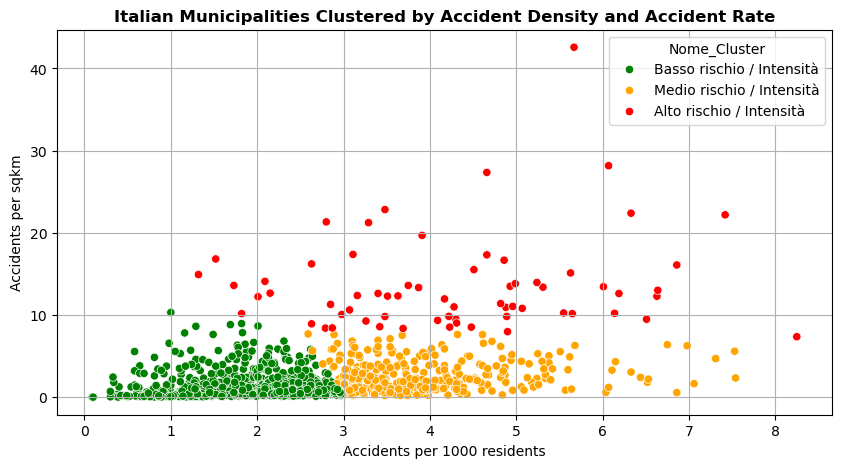

In [29]:
# Clustering plot

colors = {
    "Alto rischio / Intensità": "red",
    "Medio rischio / Intensità": "orange",
    "Basso rischio / Intensità": "green"
}

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=clean_pivot, 
    x="Accidents_per_1k_residents", 
    y="Accidents_per_kmsq", 
    hue="Nome_Cluster",
    palette=colors
)

plt.title("Italian Municipalities Clustered by Accident Density and Accident Rate", fontweight="bold")
plt.xlabel("Accidents per 1000 residents")
plt.ylabel("Accidents per sqkm")
plt.grid(True)
plt.show()

In [30]:
# I'm sorting the municipalities by highest Accidents_per_kmsq, Accidents_per_1k_residents in the high-risk cluster so I can find the most relevant municipalities to invest into

priority_municipalities = (
    clean_pivot[clean_pivot["Nome_Cluster"] == "Alto rischio / Intensità"]
    .sort_values(
        ["Accidents_per_kmsq", "Accidents_per_1k_residents"],
        ascending=False
    )
    [[
        "Comune",
        "Accidents_per_1k_residents",
        "Accidents_per_kmsq",
        "Nome_Cluster"
    ]]
    .head(20)
)

priority_municipalities

Tipo_dato,Comune,Accidents_per_1k_residents,Accidents_per_kmsq,Nome_Cluster
1272,Milano,5.67,42.58,Alto rischio / Intensità
1243,Cormano,6.07,28.17,Alto rischio / Intensità
1238,Cinisello Balsamo,4.66,27.35,Alto rischio / Intensità
199,Torino,3.48,22.83,Alto rischio / Intensità
3462,Firenze,6.33,22.39,Alto rischio / Intensità
1350,Bergamo,7.42,22.19,Alto rischio / Intensità
4208,Napoli,2.80,21.33,Alto rischio / Intensità
1245,Corsico,3.29,21.24,Alto rischio / Intensità
6180,Lissone,3.91,19.69,Alto rischio / Intensità
1240,Cologno Monzese,3.11,17.37,Alto rischio / Intensità


**Extra EDA**


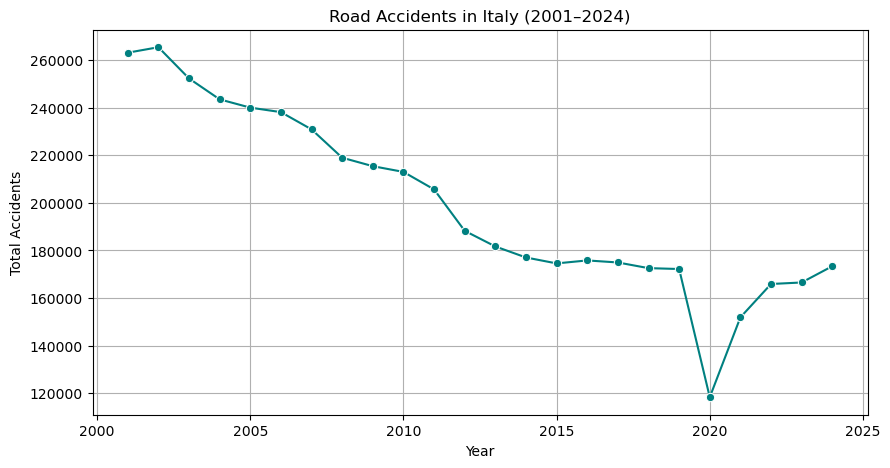

In [31]:
# Analyzing the trend of the total number of road accidents from 2001 to 2024

accidents_data = raw_df[raw_df["DATA_TYPE"] == "ROADACC"]

Historic_trend_accidents = accidents_data.groupby("TIME_PERIOD")["OBS_VALUE"].sum().reset_index()
Historic_trend_accidents.columns = ["Year", "Total_Accidents"]

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(data=Historic_trend_accidents, x="Year", y="Total_Accidents", marker="o", color="teal")
plt.title("Road Accidents in Italy (2001–2024)")
plt.xlabel("Year")
plt.ylabel("Total Accidents")
plt.grid(True)
plt.show()

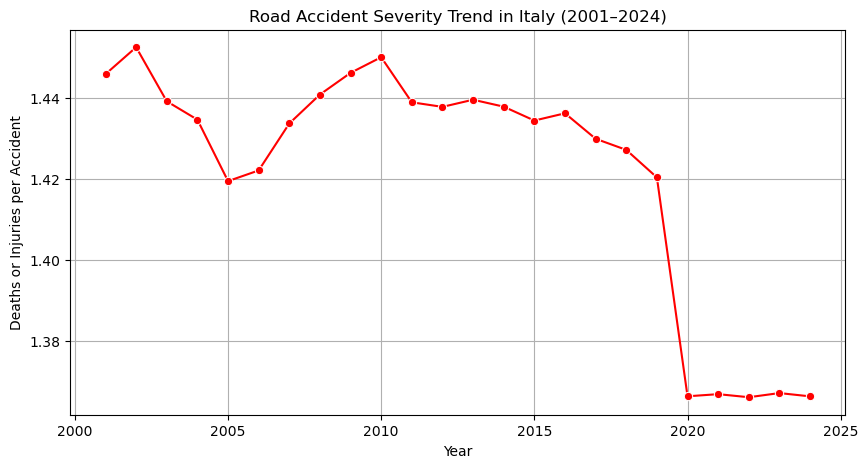

In [32]:
# Retrieving the injuries and deaths data from the original dataset

killinj_data = raw_df[raw_df["DATA_TYPE"] == "KILLINJ"]
killinj_trend = killinj_data.groupby("TIME_PERIOD")["OBS_VALUE"].sum().reset_index()

Historic_trend_accidents["Total_Deaths_Injuries"] = killinj_trend["OBS_VALUE"]
Historic_trend_accidents["Severity_Index"] = Historic_trend_accidents["Total_Deaths_Injuries"] / Historic_trend_accidents["Total_Accidents"]

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(data=Historic_trend_accidents, x="Year", y="Severity_Index", marker="o", color="red")
plt.title("Road Accident Severity Trend in Italy (2001–2024)")
plt.xlabel("Year")
plt.ylabel("Deaths or Injuries per Accident")
plt.grid(True)
plt.show()

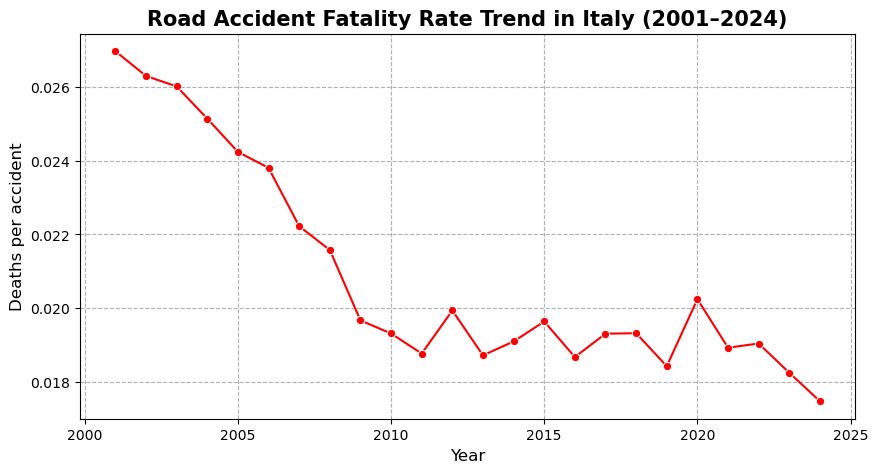

In [ ]:
# I'm repeating the same process to analyze the trend in accident fatality rates

deaths_data = raw_df[(raw_df["DATA_TYPE"] == "KILLINJ") & (raw_df["RESULT"] == "M")]
deaths_trend = deaths_data.groupby("TIME_PERIOD")["OBS_VALUE"].sum().reset_index()
deaths_trend.columns = ["Year", "Total_Deaths"]

deaths_trend = deaths_trend.sort_values("Year")
Historic_trend_accidents = Historic_trend_accidents.sort_values("Year")

Historic_trend_accidents["Total_Deaths"] = deaths_trend["Total_Deaths"]

# Calculatingthe fatality rate (Deaths / Total Accidents)
Historic_trend_accidents["Fatality_Rate"] = Historic_trend_accidents["Total_Deaths"] / Historic_trend_accidents["Total_Accidents"]

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(data=Historic_trend_accidents, x="Year", y="Fatality_Rate", marker="o", color="red")
plt.title("Road Accident Fatality Rate Trend in Italy (2001–2024)", fontsize=15, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Deaths per accident", fontsize=12)
plt.grid(True, linestyle="--")
plt.show()

In [34]:
# Exporting the final dataset so I can use it in PowerBI
clean_pivot.to_csv(
    "../data/processed/Accidents_analysis_2024.csv",
    index=False,
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)

print("File saved")

File saved
